### 0. Connecting to MLClient 

First, run `%pip show azure-ai-ml` to check if you have previously installed this package in your current **active** Python environment (kernel). If it shows `WARNING: Package(s) not found: azure-ai-ml`, please proceed to run `%pip install azure-ai-ml`.

**IMPORTANT**: Remember to also move `config.json` to the same directory you are working on.

In [1]:
#%pip show azure-ai-ml

Note: you may need to restart the kernel to use updated packages.


Uncomment and run the following cell if you saw `Package(s) not found: azure-ai-ml`.

In [ ]:
#%pip install azure-ai-ml
#%pip install azure-identity

In [1]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(
        credential=DefaultAzureCredential(),
        file_name="config.json", 
        # default is config.json, only specify if you change your file name :) 
        )

Found the config file in: ./config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


### 1. Creating a Compute Instance

**IMPORTANT**: If you failed to create a compute instance, please proceed to Azure Portal (not Azure ML), look for Storage Account `->` Settings `->` Configuration `->` Enable **storage account key access**

In [2]:
from azure.ai.ml.entities import ComputeInstance
import datetime

ci_basic_name = "basic-ci" + datetime.datetime.now().strftime("%Y%m%d%H%M")
ci_basic = ComputeInstance(name=ci_basic_name, 
                           size="STANDARD_D4s_v3",
                           idle_time_before_shutdown_minutes="60",
                           # to avoid getting charged even when you are not using :)
                           )

# This process should take about 5 minutes 
ml_client.begin_create_or_update(ci_basic).result()

ComputeInstance({'state': 'Running', 'last_operation': {'operation_name': 'Create', 'operation_time': '2026-02-18T02:29:41.916Z', 'operation_status': 'Succeeded', 'operation_trigger': 'User'}, 'os_image_metadata': <azure.ai.ml.entities._compute._image_metadata.ImageMetadata object at 0x112f264d0>, 'services': [{'display_name': 'Jupyter', 'endpoint_uri': 'https://basic-ci202602181029.southeastasia.instances.azureml.ms/tree/'}, {'display_name': 'Jupyter Lab', 'endpoint_uri': 'https://basic-ci202602181029.southeastasia.instances.azureml.ms/lab'}], 'type': 'computeinstance', 'created_on': '2026-02-18T02:29:34.425394+0000', 'provisioning_state': 'Succeeded', 'provisioning_errors': None, 'name': 'basic-ci202602181029', 'description': None, 'tags': None, 'properties': {}, 'print_as_yaml': False, 'id': '/subscriptions/6caa6f74-c995-4e27-ad38-7f1b8e526758/resourceGroups/rg-cloud-workshop/providers/Microsoft.MachineLearningServices/workspaces/SDS-Cloud-Workshop/computes/basic-ci202602181029', 'R

### 2. Submit a Training job

In [3]:
# Configuration
CURATED_ENV = "AzureML-acpt-pytorch-2.8-cuda12.6@latest"  # Pre-built PyTorch env (training)
INFERENCE_BASE_IMAGE = "mcr.microsoft.com/azureml/inference-base-2204:20260212.v1"  # Minimal AzureML inference base image
INFERENCE_CONDA_FILE = "inference-conda.yml"  # score.py runtime deps (CPU torch)
DEPLOYMENT_INSTANCE_TYPE = "STANDARD_F4s_v2"  # Azure for Students-friendly SKU
TRAIN_DATA = "azureml:train_v1:1"  # 40k samples
TEST_DATA = "azureml:test:1"

# Training hyperparameters
NUM_EPOCHS = 1      # Reduced for workshop purpose
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_WORKERS = 2

EXPERIMENT_NAME = "fmnist-workshop"

In [4]:
from azure.ai.ml import command, Input 

job = command(
    code="./",
    command=(
        "python train.py "
        "--train_dir ${{inputs.train_data}} "
        "--test_dir ${{inputs.test_data}} "
        f"--num_epochs {NUM_EPOCHS} "
        f"--batch_size {BATCH_SIZE} "
        f"--learning_rate {LEARNING_RATE} "
        f"--num_workers {NUM_WORKERS} "
        "--output_dir outputs"
    ),
    inputs={
        "train_data": Input(
            type="uri_folder",
            path=TRAIN_DATA,
            mode="ro_mount" # Read-only mount
        ),
        "test_data": Input(
            type="uri_folder",
            path=TEST_DATA,
            mode="ro_mount"
        )
    },
    environment=CURATED_ENV,
    compute=ci_basic_name,
    display_name="fmnist-training-job",
    experiment_name=EXPERIMENT_NAME,
)

ml_client.jobs.create_or_update(job)

Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Uploading Cloud (0.93 MBs): 100%|██████████| 932104/932104 [00:00<00:00, 3355112.05it/s]




Experiment,Name,Type,Status,Details Page
fmnist-workshop,magenta_circle_lz3zdl80bb,command,Starting,Link to Azure Machine Learning studio


### 3. Register a Model

In [5]:
from azure.ai.ml.entities import Model
from azure.ai.ml.constants import AssetTypes

model_name = "SimpleCNN"
job_name = "magenta_circle_lz3zdl80bb"  # REPLACEMENT needed

model = Model(
        name=model_name,
        path=f"azureml://jobs/{job_name}/outputs/artifacts/paths/outputs/model/",
        type=AssetTypes.CUSTOM_MODEL,
        description="Simple CNN model with 1 conv block",
        tags={"source_job": job_name, "version": "v1"},
    )

registered = ml_client.models.create_or_update(model)

### 4. Deploy the Model

To deploy a model, the first step is to create an **online endpoint**. Do note that the endpoint name must be unique in the entire Azure region. The common practice is to use a universally unique identifier (UUID) to create a unique name. 

In [6]:
import uuid

# Creating a unique name for the endpoint
online_endpoint = "fmnist-endpoint-" + str(uuid.uuid4())[:8]

In [7]:
from azure.ai.ml.entities import ManagedOnlineEndpoint

endpoint = ManagedOnlineEndpoint(
    name=online_endpoint,
    description="Classify 10 classes of grayscale fashion product images",
    auth_mode="key",
)

endpoint = ml_client.begin_create_or_update(endpoint).result()
print(f"Endpoint {endpoint.name} provisioning state: {endpoint.provisioning_state}")

Endpoint fmnist-endpoint-a4ca6402 provisioning state: Succeeded


In [10]:
from azure.ai.ml.entities import Environment, ManagedOnlineDeployment

# Retrieve the endpoint created
endpoint = ml_client.online_endpoints.get(name=online_endpoint)

model_ref = "azureml:SimpleCNN:1"
online_deployment = "blue"

# Create an environment 
inference_env = Environment(
    name="fmnist-inference-cpu-env",
    image=INFERENCE_BASE_IMAGE,
    conda_file=INFERENCE_CONDA_FILE,
)

# Create an online deployment
blue_deployment = ManagedOnlineDeployment(
    name=online_deployment,
    endpoint_name=online_endpoint,
    model=model_ref,
    environment=inference_env,
    code_path=".", 
    scoring_script="score.py",
    instance_type=DEPLOYMENT_INSTANCE_TYPE,
    instance_count=1,
)

blue_deployment = ml_client.begin_create_or_update(blue_deployment).result()

Check: endpoint fmnist-endpoint-a4ca6402 exists
Uploading Cloud (0.94 MBs): 100%|██████████| 944056/944056 [00:00<00:00, 2674622.23it/s]




...........................................

### 5. Real-time Inference

Now that we have the endpoint hosted on Azure, let's try that out by sending a small batch of samples for inference to validate it.


In [11]:
# Configuration
NEW_DATA = "azureml:train_v2:1"
EXPERIMENT_NAME = "fmnist-workshop"

# Endpoint info 
ENDPOINT_NAME = "fmnist-endpoint-a4ca6402" # REPLACEMENT needed
DEPLOYMENT_NAME = "blue"

# Number of images for inference in one request
N_SAMPLES = 32


In [12]:
request_job = command(
    code="./",
    command=(
        "python make_request.py "
        "--data_dir ${{inputs.new_data}} "
        f"--n_samples {N_SAMPLES} "
        "--output_path outputs/request.json"
    ),
    inputs={
        "new_data": Input(
            type="uri_folder",
            path=NEW_DATA,
            mode="ro_mount"
        )
    },
    environment=CURATED_ENV,
    compute=ci_basic_name,
    display_name="fmnist-make-request",
    experiment_name=EXPERIMENT_NAME,
)

request_job = ml_client.jobs.create_or_update(request_job)


Uploading Cloud (0.94 MBs): 100%|██████████| 943805/943805 [00:00<00:00, 2666327.03it/s]




Navigate to the Azure ML Workspace > Job to verify the job is completed before running the next cell.

In [14]:
import json
from pathlib import Path

download_dir = Path("request_job_outputs")
download_dir.mkdir(exist_ok=True)

ml_client.jobs.download(
    name=request_job.name,
    download_path=str(download_dir)
)

In [15]:
request_file = Path(download_dir, "artifacts", "outputs", "request.json")
manifest_file = Path(download_dir, "artifacts", "outputs", "manifest.json")

manifest = json.loads(manifest_file.read_text())

In [16]:
response = ml_client.online_endpoints.invoke(
    endpoint_name=ENDPOINT_NAME,
    deployment_name=DEPLOYMENT_NAME,
    request_file=str(request_file),
)

result = json.loads(response)
if isinstance(result, str):
    result = json.loads(result)

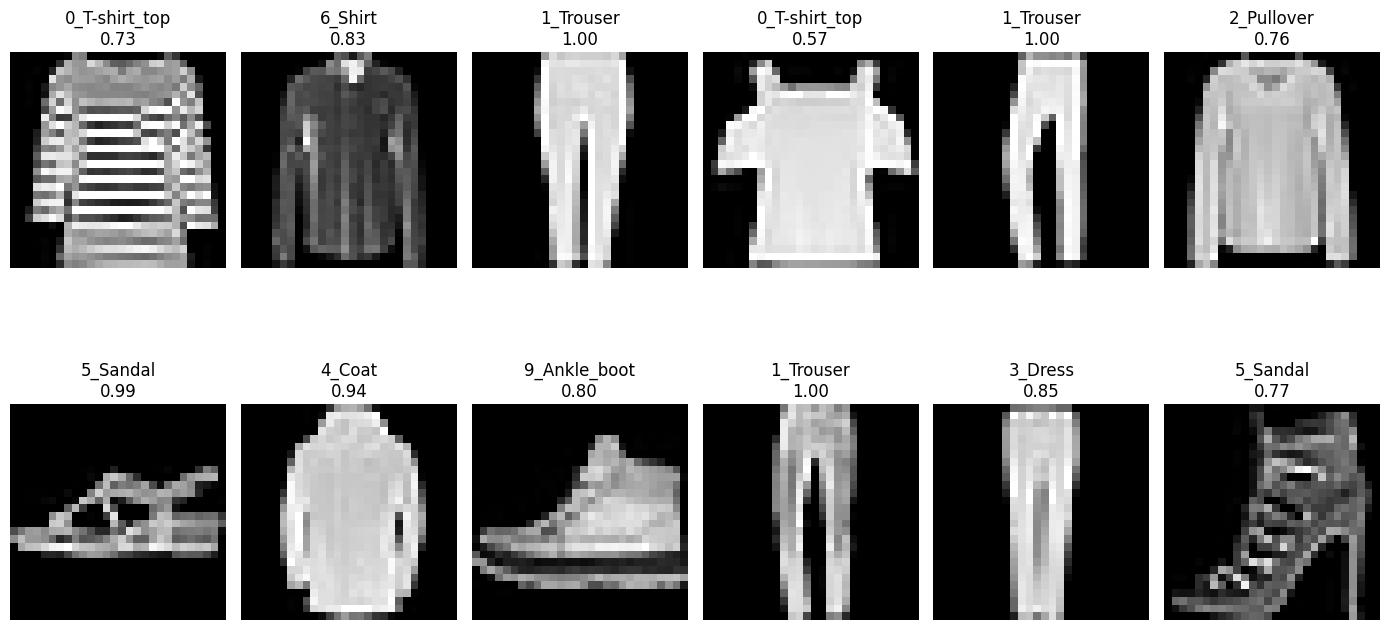

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

k = min(12, len(manifest))  # show first 12
cols = 6
rows = (k + cols - 1) // cols

plt.figure(figsize=(14, 4 * rows))
for j in range(k):
    sample_rel = manifest[j]["sample_file"]                             # like "outputs/samples/000.png"
    sample_path = Path(download_dir, "artifacts", sample_rel)           # make it local
    img = Image.open(sample_path)

    pred_name = result["prediction_names"][j]
    conf = result["confidence"][j]

    ax = plt.subplot(rows, cols, j + 1)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{pred_name}\n{conf:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()